# BLINKIT GROCERIES APP SALES ANALYSIS (SQL + Python)

This notebook connects to a MySQL/MariaDB database (`online-app-sales`) containing 5 relational tables built from Kaggle's *Blinkit Sales Dataset*, runs the core analysis queries in SQL, and visualizes the results with Python.

**Database:** `customers`, `products`, `orders`, `order_items`, `delivery_performance`
**Tools:** MySQL (via XAMPP), Python, `mysql-connector-python`, Pandas, Matplotlib

See `schema.sql` for the full table definitions and query reference.

## 1. Connect to the database

In [3]:
!pip install sqlalchemy mysql-connector-python --quiet

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams["figure.dpi"] = 120
os.makedirs("charts", exist_ok=True)

conn = create_engine(
    "mysql+mysqlconnector://root:@localhost:3306/online-app-sales"
)

with conn.connect() as test:
    print("Connected: True")

Connected: True


## 2. Quick KPIs

In [2]:
kpis = pd.read_sql("""
    SELECT
        (SELECT SUM(oi.quantity * oi.unit_price) FROM order_items oi) AS total_revenue,
        (SELECT COUNT(*) FROM customers) AS total_customers,
        (SELECT COUNT(*) FROM products) AS total_products
""", conn)

kpis

,total_revenue,total_customers,total_products
0,4972415.43,2500,268


In [3]:
most_expensive = pd.read_sql("SELECT product_name, price FROM products ORDER BY price DESC LIMIT 1", conn)
cheapest = pd.read_sql("SELECT product_name, price FROM products ORDER BY price ASC LIMIT 1", conn)

print("Most expensive product:")
display(most_expensive)
print("\nCheapest product:")
display(cheapest)

Most expensive product:


,product_name,price
0,Vitamins,995.98



Cheapest product:


,product_name,price
0,Iced Tea,12.32


**Products that have never been sold:**

In [4]:
never_sold = pd.read_sql("""
    SELECT p.product_id, p.product_name, p.category
    FROM products p
    LEFT JOIN order_items oi ON p.product_id = oi.product_id
    WHERE oi.product_id IS NULL
""", conn)

print(f"{len(never_sold)} product(s) have never been sold.")
never_sold

0 product(s) have never been sold.


,product_id,product_name,category


**Customers who bought more than one distinct product:**

In [5]:
distinct_products_per_customer = pd.read_sql("""
    WITH distinct_products AS (
        SELECT
            o.customer_id,
            c.customer_name,
            COUNT(DISTINCT oi.product_id) AS distinct_products
        FROM orders o
        JOIN order_items oi ON oi.order_id = o.order_id
        JOIN customers c ON c.customer_id = o.customer_id
        GROUP BY o.customer_id, c.customer_name
    )
    SELECT * FROM distinct_products
    WHERE distinct_products > 1
    ORDER BY distinct_products DESC
""", conn)

print(f"{len(distinct_products_per_customer)} customer(s) bought more than one distinct product.")
distinct_products_per_customer.head(10)

1490 customer(s) bought more than one distinct product.


,customer_id,customer_name,distinct_products
0,77869660,Nidhi Sha,9
1,17805991,Jhalak Rai,8
2,93018527,Lekha Rout,7
3,10562528,Udant Dada,7
4,26285589,Bakhshi De,7
5,75213636,Bhanumati Chatterjee,7
6,21701991,Wazir Hari,7
7,12832151,Ekavir Bhalla,7
8,13604883,Siddharth Kata,7
9,8791577,Warda Kohli,7


## 3. Best & worst-selling products

In [6]:
top_products = pd.read_sql("""
    SELECT p.product_name, SUM(oi.quantity) AS units_sold
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    GROUP BY p.product_id
    ORDER BY units_sold DESC
    LIMIT 10
""", conn)

top_products

,product_name,units_sold
0,Baby Food,70.0
1,Baby Wipes,68.0
2,Toilet Cleaner,62.0
3,Mangoes,61.0
4,Pain Reliever,60.0
5,Bread,58.0
6,Milk,56.0
7,Cough Syrup,56.0
8,Cough Syrup,55.0
9,Vitamins,55.0


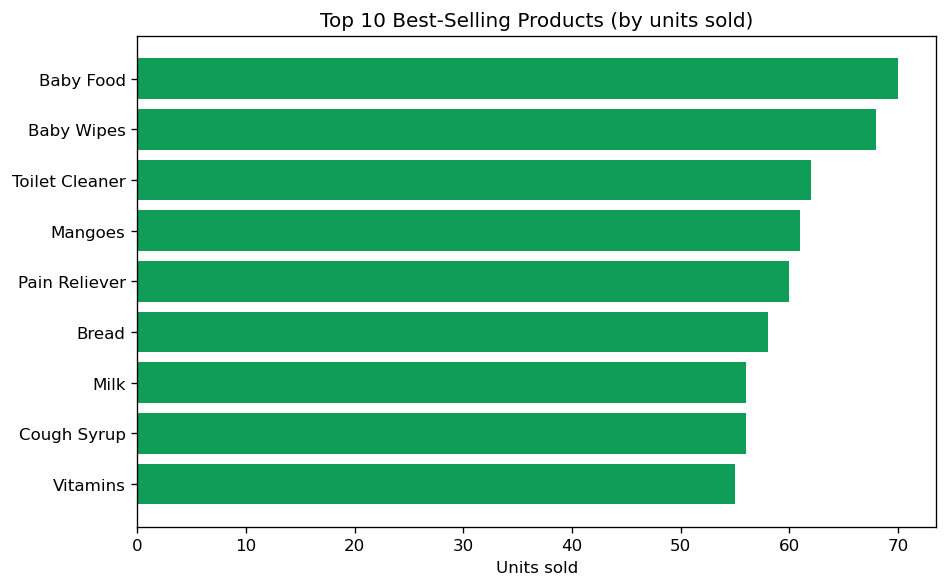

In [7]:
plt.figure(figsize=(8, 5))
plt.barh(top_products["product_name"][::-1], top_products["units_sold"][::-1], color="#0F9D58")
plt.title("Top 10 Best-Selling Products (by units sold)")
plt.xlabel("Units sold")
plt.tight_layout()
plt.savefig("charts/top_products.png")
plt.show()

In [8]:
bottom_products = pd.read_sql("""
    SELECT p.product_name, SUM(oi.quantity) AS units_sold
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    GROUP BY p.product_id
    ORDER BY units_sold ASC
    LIMIT 10
""", conn)

bottom_products

,product_name,units_sold
0,Pain Reliever,9.0
1,Onions,13.0
2,Detergent,17.0
3,Eggs,19.0
4,Pain Reliever,20.0
5,Cola,21.0
6,Frozen Biryani,22.0
7,Lotion,22.0
8,Dog Food,23.0
9,Biscuits,23.0


## 4. Monthly revenue trend

In [16]:
monthly_revenue = pd.read_sql("""
    SELECT DATE_FORMAT(order_date, '%Y-%m') AS month, SUM(order_total) AS revenue
    FROM orders
    GROUP BY month
    ORDER BY month
""", conn)

# Drop the first/last month if incomplete (fewer than 150 orders), so the
# trend doesn't show a misleading spike or drop caused by partial data.
order_counts = pd.read_sql("""
    SELECT DATE_FORMAT(order_date, '%Y-%m') AS month, COUNT(*) AS n
    FROM orders GROUP BY month ORDER BY month
""", conn)
if order_counts.iloc[-1]["n"] < 150:
    monthly_revenue = monthly_revenue.iloc[:-1]
if order_counts.iloc[0]["n"] < 150:
    monthly_revenue = monthly_revenue.iloc[1:]

monthly_revenue

,month,revenue
1,2023-04,554344.77
2,2023-05,608213.54
3,2023-06,505227.66
4,2023-07,567639.91
5,2023-08,623472.35
6,2023-09,571117.81
7,2023-10,578369.83
8,2023-11,567783.74
9,2023-12,615709.03
10,2024-01,560423.56


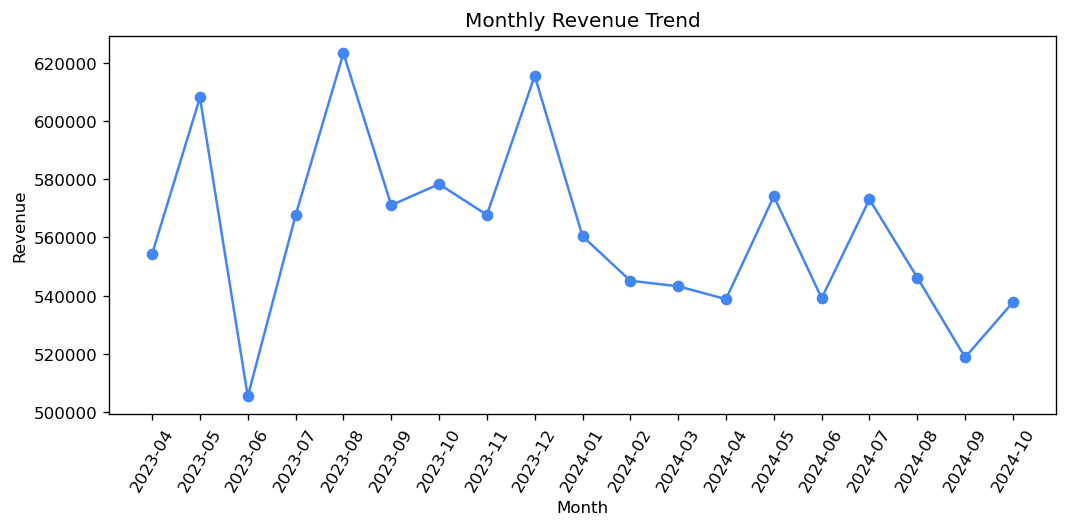

In [10]:
plt.figure(figsize=(9, 4.5))
plt.plot(monthly_revenue["month"], monthly_revenue["revenue"], marker="o", color="#4285F4")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig("charts/monthly_revenue.png")
plt.show()

## 5. Customer segmentation (Premium / Frequent / Occasional)

In [11]:
customer_tiers = pd.read_sql("""
    WITH customer_totals AS (
        SELECT c.customer_id, COUNT(o.order_id) AS total_orders
        FROM customers c
        JOIN orders o ON o.customer_id = c.customer_id
        GROUP BY c.customer_id
    )
    SELECT
        CASE
            WHEN total_orders >= 5 THEN 'Premium'
            WHEN total_orders BETWEEN 2 AND 4 THEN 'Frequent'
            ELSE 'Occasional'
        END AS customer_tier,
        COUNT(*) AS num_customers
    FROM customer_totals
    GROUP BY customer_tier
""", conn)

order_map = {"Premium": 0, "Frequent": 1, "Occasional": 2}
customer_tiers = customer_tiers.sort_values("customer_tier", key=lambda s: s.map(order_map))
customer_tiers

,customer_tier,num_customers
2,Premium,121
0,Frequent,1371
1,Occasional,680


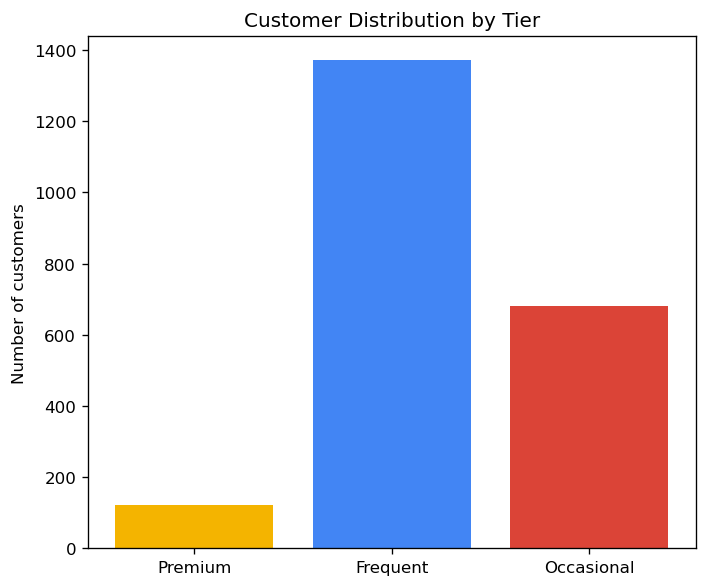

In [12]:
plt.figure(figsize=(6, 5))
colors = ["#F4B400", "#4285F4", "#DB4437"]
plt.bar(customer_tiers["customer_tier"], customer_tiers["num_customers"], color=colors)
plt.title("Customer Distribution by Tier")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.savefig("charts/customer_tiers.png")
plt.show()

## 6. Delivery performance

In [13]:
delivery_status = pd.read_sql("""
    SELECT delivery_status, COUNT(*) AS num_orders,
           ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM orders), 1) AS pct
    FROM orders
    GROUP BY delivery_status
""", conn)

delivery_status

,delivery_status,num_orders,pct
0,On Time,3470,69.4
1,Significantly Delayed,493,9.9
2,Slightly Delayed,1037,20.7


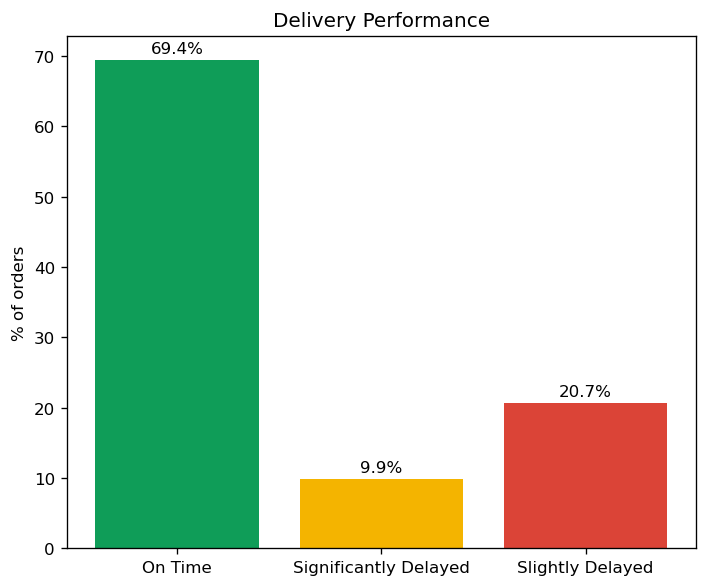

In [14]:
plt.figure(figsize=(6, 5))
colors2 = ["#0F9D58", "#F4B400", "#DB4437"]
plt.bar(delivery_status["delivery_status"], delivery_status["pct"], color=colors2)
plt.title("Delivery Performance")
plt.ylabel("% of orders")
for i, v in enumerate(delivery_status["pct"]):
    plt.text(i, v + 1, f"{v}%", ha="center")
plt.tight_layout()
plt.savefig("charts/delivery_performance.png")
plt.show()

## 7. Close the connection

In [15]:
conn.dispose()
print("Connection closed. Charts saved to /charts")

Connection closed. Charts saved to /charts


## Key insights

- **Best-sellers:** *Baby Food*, *Baby Wipes*, and *Toilet Cleaner* are the top 3 products by units sold — everyday essentials dominate.
- **Every product has sold at least once:** the "never sold" query returns 0 results — a sign that there isn't dead stock.
- **Revenue is stable, not seasonal:** monthly revenue holds steady in the ~505K–623K range with no major upward or downward trend.
- **Customer base skews "Frequent":** most customers (1,371) fall into the Frequent tier (2-4 orders), with a smaller loyal Premium segment (121) and a large Occasional group (680) that could be targeted for a re-engagement campaign.
- **Delivery isn't fully reliable:** ~69% of orders arrive on time, but nearly 1 in 10 (9.9%) are *significantly* delayed — worth flagging as an operational risk and worthy of an evaluation.